In [2]:
import csv
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import matplotlib.cm as cm

In [3]:
df = pd.read_csv('thesis__data.csv', usecols = ['YEAR', 'AGE', 'MORTSTAT', 'MORTDODY', 'ALCAMT', 'SEX'])

In [4]:
# remove what has to be removed
df = df[(df['MORTSTAT'] == 1) | (df['MORTSTAT'] == 2)]
df = df[(df['SEX'] == 1) | (df['SEX'] == 2)]

# define year of birth
df['YEAR_BIRTH'] = df['YEAR'] - df['AGE']

In [5]:
# computes the average number of people at each age over years
def avr_P_i(df, years, age_min, age_max):
    
    standardization_df = pd.DataFrame(index=years, columns=range(age_min, age_max + 1))
    
    for year in years:
        df_use = df[(df['MORTDODY'] >= year) & (df['YEAR'] <= year)].copy()

        # define age of these people in year 
        df_use['AGE_year'] = year - df_use['YEAR_BIRTH']
        df_use = df_use[df_use['AGE_year'] <= age_max]

        # count occurrences of each age for the year
        age_count = df_use['AGE_year'].value_counts().reindex(range(age_min, age_max + 1), fill_value=0)

        # assign the counts to the standardization DataFrame
        standardization_df.loc[year] = age_count.values
        
    mean_count = standardization_df.mean()
    
    return mean_count 

In [6]:
# pre-selection
age_min = 18
age_max = 80

In [7]:
# ALCAMT

In [8]:
# fix universe 
df_aa = df.copy()
df_aa = df_aa[(df_aa['ALCAMT']<=95)]

df_aa['ALCAMT'] = df_aa['ALCAMT'].apply(lambda x: 0 if 0 == x else x)
df_aa['ALCAMT'] = df_aa['ALCAMT'].apply(lambda x: 1 if 1 <= x <= 2 else x)
df_aa['ALCAMT'] = df_aa['ALCAMT'].apply(lambda x: 2 if 3 <= x <= 4 else x)
df_aa['ALCAMT'] = df_aa['ALCAMT'].apply(lambda x: 3 if 5 <= x <= 7 else x)
df_aa['ALCAMT'] = df_aa['ALCAMT'].apply(lambda x: 4 if 8 <= x else x)

In [9]:
# get populations
populations = sorted(df_aa['ALCAMT'].unique())

# initialize DataFrames to store SMR (standardized mortality rates) for each year
years = list(range(1997, df_aa['YEAR'].max()+2))
smr_aa = pd.DataFrame(index=years, columns=populations)  

# track agining of population
age_avr = pd.DataFrame(index=years, columns=populations)

mean_count = avr_P_i(df_aa, years, age_min, age_max)

for year in years:
    # people who were alive at the beginning of year i  
    df_year = df_aa[(df_aa['MORTDODY'] >= year) & (df_aa['YEAR'] <= year)].copy()

    # define age of these people in year i
    df_year['AGE_year'] = year - df_year['YEAR_BIRTH']
    df_year = df_year[df_year['AGE_year'] <= age_max]
    
    # age counts (used for standardization)
    age_counts = []
    for age in range(age_min, age_max + 1):
        age_counts.append(df_year[df_year['AGE_year'] == age].shape[0])
    
    for population in populations:
        # work with one population at the time
        df_year_population  = df_year[df_year['ALCAMT'] == population]
        
        age_avr.at[year, population] = (df_year_population['AGE_year'].mean())
        
        # counts:
        count_all = []
        count_dead = []
        for age in range(age_min, age_max + 1):
            total_count = df_year_population[df_year_population['AGE_year'] == age].shape[0]
            dead_count = df_year_population[(df_year_population['MORTDODY'] == year) & (df_year_population['AGE_year'] == age)].shape[0]
            
            count_all.append(total_count)
            count_dead.append(dead_count)
        
        mr_per_age = [dead / total if total > 0 else 0 for dead, total in zip(count_dead, count_all)]
        
        smr_aa.at[year, population] = sum([a*b for a,b in zip(mr_per_age, mean_count)])/sum(mean_count)       

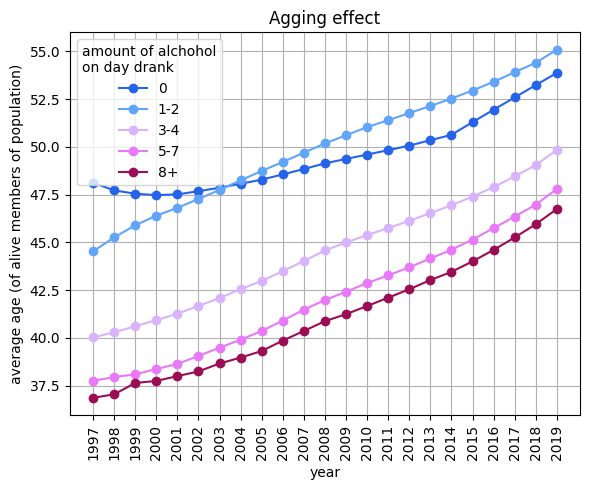

In [10]:
plt.figure(figsize=(6, 5))
labels = {0: '0', 1: '1-2', 2: '3-4', 3: '5-7', 4: '8+'}
colors = ['#2563EB', '#60A5FA', '#D8B4FE', '#E879F9', '#9B0D54']

for i, population in enumerate(populations):
    plt.plot(age_avr.index, age_avr[population], marker='o', label=labels[population], color=colors[i])

plt.title('Agging effect')
plt.xlabel('year')
plt.ylabel('average age (of alive members of population)')
plt.xticks(smr_aa.index, rotation=90)  
plt.legend(title='amount of alchohol\non day drank')
plt.grid()
plt.tight_layout()
plt.savefig('aamt_poverty.jpg', format='jpg')
plt.show()

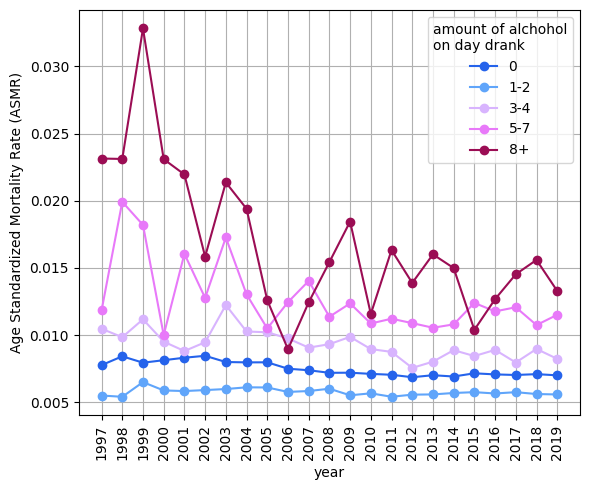

In [11]:
plt.figure(figsize=(6, 5))

for i, population in enumerate(populations):
    plt.plot(smr_aa.index, smr_aa[population], marker='o', label=labels[population], color=colors[i])

plt.xlabel('year')
plt.ylabel('Age Standardized Mortality Rate (ASMR)')
plt.xticks(smr_aa.index, rotation=90)  
plt.legend(title='amount of alchohol\non day drank')
plt.grid()
plt.tight_layout()
plt.savefig('smr_aamt.jpg', format='jpg')
plt.show()

In [12]:
# use smr for years after 2000
smr_2000  = smr_aa[smr_aa.index >= 2000]

# compute average per population
smr_mean = smr_2000.mean()

# define custom labels for x-axis
custom_labels = ['0', '1-2', '3-4', '5-7', '8+']  

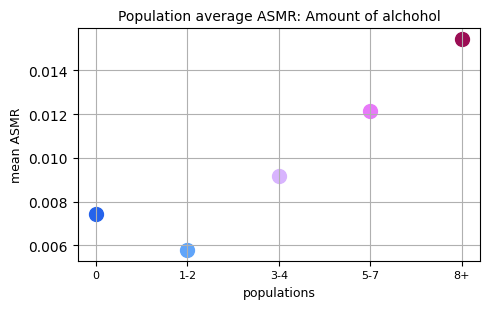

In [13]:
# scatter plot with custom colors
plt.figure(figsize=(5, 3.2))

# loop through the points and color them
for i, (x, y) in enumerate(zip(smr_mean.index, smr_mean.values)):
    plt.scatter(x, y, color=colors[i], s=100)

plt.title('Population average ASMR: Amount of alchohol', fontsize=10)
plt.xlabel('populations', fontsize=9)
plt.ylabel('mean ASMR', fontsize=9)
plt.xticks(smr_mean.index, custom_labels, rotation=0, fontsize=8)  
plt.xticks(fontsize=8) 
plt.tight_layout()  
plt.grid(True)  
plt.savefig('avr_amr_aamt.jpg', format='jpg')
plt.show()